In [66]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

In [67]:
df=pd.read_csv('beer-servings.csv')
df

,Unnamed: 0,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,continent
0,0,Afghanistan,0.0,0.0,0.0,0.0,Asia
1,1,Albania,89.0,132.0,54.0,4.9,Europe
2,2,Algeria,25.0,0.0,14.0,0.7,Africa
3,3,Andorra,245.0,138.0,312.0,12.4,Europe
4,4,Angola,217.0,57.0,45.0,5.9,Africa
...,...,...,...,...,...,...,...
188,188,Venezuela,NaN,100.0,3.0,7.7,South America
189,189,Vietnam,111.0,2.0,1.0,2.0,Asia
190,190,Yemen,6.0,0.0,0.0,0.1,Asia
191,191,Zambia,32.0,19.0,4.0,2.5,Africa


In [68]:
df.head()

,Unnamed: 0,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,continent
0,0,Afghanistan,0.0,0.0,0.0,0.0,Asia
1,1,Albania,89.0,132.0,54.0,4.9,Europe
2,2,Algeria,25.0,0.0,14.0,0.7,Africa
3,3,Andorra,245.0,138.0,312.0,12.4,Europe
4,4,Angola,217.0,57.0,45.0,5.9,Africa


In [69]:
df.tail()

,Unnamed: 0,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,continent
188,188,Venezuela,NaN,100.0,3.0,7.7,South America
189,189,Vietnam,111.0,2.0,1.0,2.0,Asia
190,190,Yemen,6.0,0.0,0.0,0.1,Asia
191,191,Zambia,32.0,19.0,4.0,2.5,Africa
192,192,Zimbabwe,64.0,18.0,4.0,4.7,Africa


In [70]:
df.shape

(193, 7)

In [71]:
df.columns

Index(['Unnamed: 0', 'country', 'beer_servings', 'spirit_servings',
       'wine_servings', 'total_litres_of_pure_alcohol', 'continent'],
      dtype='object')

In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193 entries, 0 to 192
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Unnamed: 0                    193 non-null    int64  
 1   country                       193 non-null    object 
 2   beer_servings                 185 non-null    float64
 3   spirit_servings               185 non-null    float64
 4   wine_servings                 187 non-null    float64
 5   total_litres_of_pure_alcohol  192 non-null    float64
 6   continent                     193 non-null    object 
dtypes: float64(4), int64(1), object(2)
memory usage: 10.7+ KB


In [73]:
df.describe(include='all')

,Unnamed: 0,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,continent
count,193.000000,193,185.000000,185.000000,187.000000,192.000000,193
unique,NaN,193,NaN,NaN,NaN,NaN,6
top,NaN,Afghanistan,NaN,NaN,NaN,NaN,Africa
freq,NaN,1,NaN,NaN,NaN,NaN,53
mean,96.000000,NaN,105.124324,83.221622,50.165775,4.741667,NaN
std,55.858452,NaN,100.524714,89.142958,80.358868,3.767654,NaN
min,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,NaN
25%,48.000000,NaN,20.000000,4.000000,1.000000,1.300000,NaN
50%,96.000000,NaN,76.000000,60.000000,9.000000,4.250000,NaN
75%,144.000000,NaN,185.000000,132.000000,60.500000,7.200000,NaN


In [74]:
df.dtypes

Unnamed: 0                        int64
country                          object
beer_servings                   float64
spirit_servings                 float64
wine_servings                   float64
total_litres_of_pure_alcohol    float64
continent                        object
dtype: object

In [75]:
# drop unvanted column
df.drop('Unnamed: 0',axis=1,inplace=True)

In [76]:
# step 1: null handling
# detect
df.isnull().sum()

country                         0
beer_servings                   8
spirit_servings                 8
wine_servings                   6
total_litres_of_pure_alcohol    1
continent                       0
dtype: int64

In [77]:
# remove all rows with 1 notna value and all others are nan
df.dropna(thresh=df.shape[1]-1,inplace=True) # remove rows with 1 nonna
df

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,continent
0,Afghanistan,0.0,0.0,0.0,0.0,Asia
1,Albania,89.0,132.0,54.0,4.9,Europe
2,Algeria,25.0,0.0,14.0,0.7,Africa
3,Andorra,245.0,138.0,312.0,12.4,Europe
4,Angola,217.0,57.0,45.0,5.9,Africa
...,...,...,...,...,...,...
188,Venezuela,NaN,100.0,3.0,7.7,South America
189,Vietnam,111.0,2.0,1.0,2.0,Asia
190,Yemen,6.0,0.0,0.0,0.1,Asia
191,Zambia,32.0,19.0,4.0,2.5,Africa


array([[<Axes: title={'center': 'beer_servings'}>,
        <Axes: title={'center': 'spirit_servings'}>],
       [<Axes: title={'center': 'wine_servings'}>,
        <Axes: title={'center': 'total_litres_of_pure_alcohol'}>]],
      dtype=object)

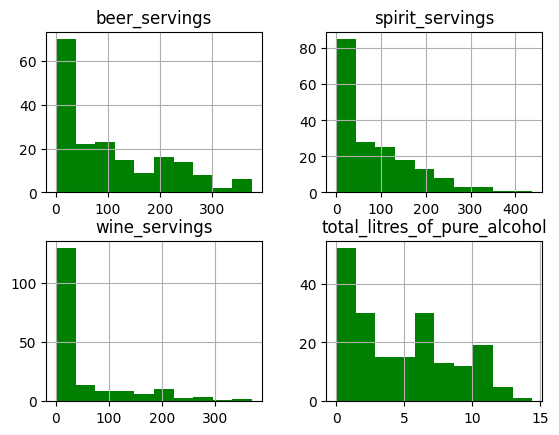

In [78]:
# imputating null value
fg=df.select_dtypes("number")
fg.hist(color='green')
# if it is bell shape impute with mean else with median
# for category imput with mode

In [79]:
df.fillna(df[df.select_dtypes('number').columns].median(),inplace=True) # impute with median
df

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,continent
0,Afghanistan,0.0,0.0,0.0,0.0,Asia
1,Albania,89.0,132.0,54.0,4.9,Europe
2,Algeria,25.0,0.0,14.0,0.7,Africa
3,Andorra,245.0,138.0,312.0,12.4,Europe
4,Angola,217.0,57.0,45.0,5.9,Africa
...,...,...,...,...,...,...
188,Venezuela,76.0,100.0,3.0,7.7,South America
189,Vietnam,111.0,2.0,1.0,2.0,Asia
190,Yemen,6.0,0.0,0.0,0.1,Asia
191,Zambia,32.0,19.0,4.0,2.5,Africa


In [80]:
# check for null
df.isnull().sum()

country                         0
beer_servings                   0
spirit_servings                 0
wine_servings                   0
total_litres_of_pure_alcohol    0
continent                       0
dtype: int64

([0, 1, 2, 3],
 [Text(0, 0, 'beer_servings'),
  Text(1, 0, 'spirit_servings'),
  Text(2, 0, 'wine_servings'),
  Text(3, 0, 'total_litres_of_pure_alcohol')])

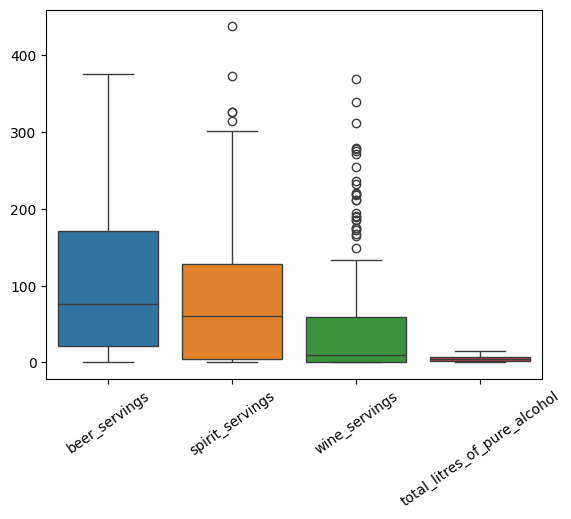

In [81]:
# step 2 : outlier handling
# detect outliers
sns.boxplot(df[df.select_dtypes('number').columns])
plt.xticks(rotation=35)


In [82]:
for i in df.select_dtypes('number').columns:
    q1=df[i].quantile(0.25)
    q3=df[i].quantile(0.75)
    iqr=q3-q1
    lo=q1-1.5*iqr
    hi=q3+1.5*iqr
    out=(df[i]<lo) | (df[i]>hi)
    print(out.sum())
    df.loc[out,i]=np.log1p(df.loc[out, i]) # log transform the outliers

0
5
26
0


([0, 1, 2, 3],
 [Text(0, 0, 'beer_servings'),
  Text(1, 0, 'spirit_servings'),
  Text(2, 0, 'wine_servings'),
  Text(3, 0, 'total_litres_of_pure_alcohol')])

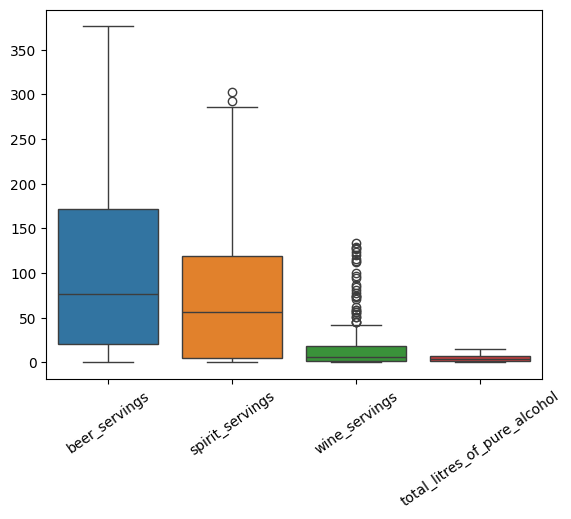

In [83]:
sns.boxplot(df[df.select_dtypes('number').columns])
plt.xticks(rotation=35)

In [84]:
df.reset_index(drop=True,inplace=True)
df

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,continent
0,Afghanistan,0.0,0.0,0.000000,0.0,Asia
1,Albania,89.0,132.0,54.000000,4.9,Europe
2,Algeria,25.0,0.0,14.000000,0.7,Africa
3,Andorra,245.0,138.0,5.746203,12.4,Europe
4,Angola,217.0,57.0,45.000000,5.9,Africa
...,...,...,...,...,...,...
187,Venezuela,76.0,100.0,3.000000,7.7,South America
188,Vietnam,111.0,2.0,1.000000,2.0,Asia
189,Yemen,6.0,0.0,0.000000,0.1,Asia
190,Zambia,32.0,19.0,4.000000,2.5,Africa


([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'Asia'),
  Text(1, 0, 'Europe'),
  Text(2, 0, 'Africa'),
  Text(3, 0, 'North America'),
  Text(4, 0, 'South America'),
  Text(5, 0, 'Oceania')])

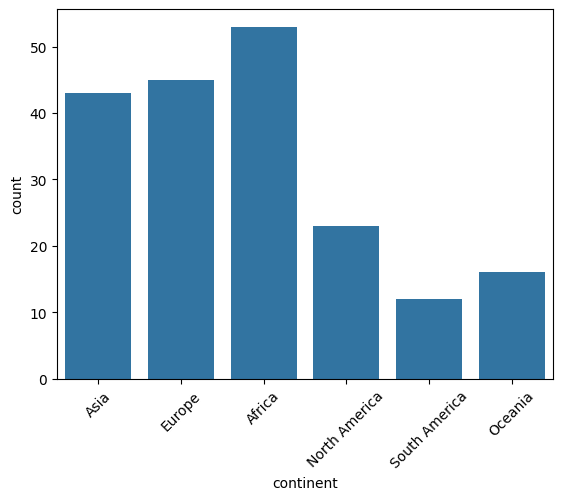

In [85]:
# step 3 : encoding
# label encoding
df.select_dtypes(include=['string','object'])
sns.countplot(data=df,x='continent')
plt.xticks(rotation=45)

In [86]:
for i in df.select_dtypes(include=['string','object']).columns:
    print(i,df[i].nunique())

country 192
continent 6


In [87]:
# handling categorical values
df.drop('country',axis=1,inplace=True)
df

,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,continent
0,0.0,0.0,0.000000,0.0,Asia
1,89.0,132.0,54.000000,4.9,Europe
2,25.0,0.0,14.000000,0.7,Africa
3,245.0,138.0,5.746203,12.4,Europe
4,217.0,57.0,45.000000,5.9,Africa
...,...,...,...,...,...
187,76.0,100.0,3.000000,7.7,South America
188,111.0,2.0,1.000000,2.0,Asia
189,6.0,0.0,0.000000,0.1,Asia
190,32.0,19.0,4.000000,2.5,Africa


In [88]:
le=LabelEncoder()
df['continent']=le.fit_transform(df['continent'])
df

,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,continent
0,0.0,0.0,0.000000,0.0,1
1,89.0,132.0,54.000000,4.9,2
2,25.0,0.0,14.000000,0.7,0
3,245.0,138.0,5.746203,12.4,2
4,217.0,57.0,45.000000,5.9,0
...,...,...,...,...,...
187,76.0,100.0,3.000000,7.7,5
188,111.0,2.0,1.000000,2.0,1
189,6.0,0.0,0.000000,0.1,1
190,32.0,19.0,4.000000,2.5,0


In [89]:
df.reset_index(drop=True,inplace=True)
df

,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,continent
0,0.0,0.0,0.000000,0.0,1
1,89.0,132.0,54.000000,4.9,2
2,25.0,0.0,14.000000,0.7,0
3,245.0,138.0,5.746203,12.4,2
4,217.0,57.0,45.000000,5.9,0
...,...,...,...,...,...
187,76.0,100.0,3.000000,7.7,5
188,111.0,2.0,1.000000,2.0,1
189,6.0,0.0,0.000000,0.1,1
190,32.0,19.0,4.000000,2.5,0


In [90]:
# final step 4: scaling
from sklearn.preprocessing import MinMaxScaler
df2=df.drop(['total_litres_of_pure_alcohol','continent'],axis=1)
df2

,beer_servings,spirit_servings,wine_servings
0,0.0,0.0,0.000000
1,89.0,132.0,54.000000
2,25.0,0.0,14.000000
3,245.0,138.0,5.746203
4,217.0,57.0,45.000000
...,...,...,...
187,76.0,100.0,3.000000
188,111.0,2.0,1.000000
189,6.0,0.0,0.000000
190,32.0,19.0,4.000000


In [91]:
df3=df[['total_litres_of_pure_alcohol','continent']]
df3

,total_litres_of_pure_alcohol,continent
0,0.0,1
1,4.9,2
2,0.7,0
3,12.4,2
4,5.9,0
...,...,...
187,7.7,5
188,2.0,1
189,0.1,1
190,2.5,0


In [92]:
minmax=MinMaxScaler(feature_range=(0,1))
df2=minmax.fit_transform(df2)
df2

array([[0.        , 0.        , 0.        ],
       [0.23670213, 0.43708609, 0.40298507],
       [0.06648936, 0.        , 0.10447761],
       [0.65159574, 0.45695364, 0.04288211],
       [0.57712766, 0.18874172, 0.3358209 ],
       [0.2712766 , 0.42384106, 0.3358209 ],
       [0.20212766, 0.08278146, 0.04031849],
       [0.05585106, 0.59271523, 0.08208955],
       [0.69414894, 0.2384106 , 0.04000964],
       [0.74202128, 0.24834437, 0.03923504],
       [0.05585106, 0.15231788, 0.03731343],
       [0.32446809, 0.58278146, 0.38059701],
       [0.11170213, 0.20860927, 0.05223881],
       [0.38031915, 0.57284768, 0.26865672],
       [0.37765957, 0.01961674, 0.31343284],
       [0.78457447, 0.2781457 , 0.04000964],
       [0.69946809, 0.37748344, 0.05970149],
       [0.09042553, 0.01324503, 0.09701493],
       [0.06117021, 0.        , 0.        ],
       [0.44414894, 0.13576159, 0.05970149],
       [0.20212766, 0.57284768, 0.05970149],
       [0.46010638, 0.11589404, 0.26119403],
       [0.

In [93]:
df2=pd.DataFrame(df2)
df2

,0,1,2
0,0.000000,0.000000,0.000000
1,0.236702,0.437086,0.402985
2,0.066489,0.000000,0.104478
3,0.651596,0.456954,0.042882
4,0.577128,0.188742,0.335821
...,...,...,...
187,0.202128,0.331126,0.022388
188,0.295213,0.006623,0.007463
189,0.015957,0.000000,0.000000
190,0.085106,0.062914,0.029851


In [94]:
df2.columns=['beer_servings','spirit_servings','wine_servings']
df2

,beer_servings,spirit_servings,wine_servings
0,0.000000,0.000000,0.000000
1,0.236702,0.437086,0.402985
2,0.066489,0.000000,0.104478
3,0.651596,0.456954,0.042882
4,0.577128,0.188742,0.335821
...,...,...,...
187,0.202128,0.331126,0.022388
188,0.295213,0.006623,0.007463
189,0.015957,0.000000,0.000000
190,0.085106,0.062914,0.029851


In [95]:
df2=pd.concat([df2,df3],axis=1)
df2

,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,continent
0,0.000000,0.000000,0.000000,0.0,1
1,0.236702,0.437086,0.402985,4.9,2
2,0.066489,0.000000,0.104478,0.7,0
3,0.651596,0.456954,0.042882,12.4,2
4,0.577128,0.188742,0.335821,5.9,0
...,...,...,...,...,...
187,0.202128,0.331126,0.022388,7.7,5
188,0.295213,0.006623,0.007463,2.0,1
189,0.015957,0.000000,0.000000,0.1,1
190,0.085106,0.062914,0.029851,2.5,0


In [96]:
df2.describe()

,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,continent
count,192.000000,192.000000,192.000000,192.000000,192.000000
mean,0.276762,0.242607,0.143165,4.741667,1.697917
std,0.262811,0.250760,0.235708,3.767654,1.504755
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.055851,0.015728,0.007463,1.300000,0.000000
50%,0.202128,0.187086,0.041594,4.250000,1.500000
75%,0.456117,0.394040,0.134328,7.200000,3.000000
max,1.000000,1.000000,1.000000,14.400000,5.000000


In [97]:
# completed
